# VEP Case Studies

Examplar results from the VEP pipeline investigating well-known disease-associated variants.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 

pd.set_option('display.max_columns', None)

First, let's count how many results we have for each model/scoring strategy.

In [55]:
vep_files = va.list_vep_files(as_df=True)
print(vep_files.shape)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/3 [00:00<?, ?it/s]

Found 364272 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 6
>> scoring_strategy: 3
>> variant_set: 1
>> haplotype: 85106
>> protein: 2142
(364272, 6)


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:793S>I,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:1106V>A,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [3]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins.loc[candidate_proteins['RefSeq Protein'].isin(vep_files['protein'])]

,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000376802,NP_000286
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000155840,NP_000209
10,KCNH2,Potassium Voltage-Gated Channel Subfamily H Me...,NP_000229.1,NM_000238.4,ENSP00000262186,NP_000229


## BRCA1

In [16]:
gene = "BRCA1"
brca1 = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['protein'].isin(
        candidate_proteins.loc[candidate_proteins['Gene']==gene]['RefSeq Protein']
            ))]
            )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 874 masked-marginals parquet files


Reading files:   0%|          | 0/874 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 4.76GB/s]
/home/schilder/projects/VEP_protein/src/vep_analysis.py:189: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.
  pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])


VEP dataframe shape: (398544, 72)


In [ ]:
brca1 = hs.add_haplotype_freqs(brca1) 

In [132]:
brca1.head()

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC,freq_1000GENOMES:phase_3:ACB,freq_1000GENOMES:phase_3:AFR,freq_1000GENOMES:phase_3:ALL,freq_1000GENOMES:phase_3:AMR,freq_1000GENOMES:phase_3:ASW,freq_1000GENOMES:phase_3:BEB,freq_1000GENOMES:phase_3:CDX,freq_1000GENOMES:phase_3:CEU,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:EAS,freq_1000GENOMES:phase_3:ESN,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:FIN,freq_1000GENOMES:phase_3:GBR,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:IBS,freq_1000GENOMES:phase_3:ITU,freq_1000GENOMES:phase_3:JPT,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:LWK,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:MXL,freq_1000GENOMES:phase_3:PEL,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:SAS,freq_1000GENOMES:phase_3:STU,freq_1000GENOMES:phase_3:TSI,freq_1000GENOMES:phase_3:YRI,top_pop,top_superpop,top_superpop_freq
69840,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,H1860Q,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-2.901947,wt-marginals,False,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045690,1748423,G,T,.,PASS,1748423,17:43045690,T,672,NM_007294.4,Transcript,missense_variant,5693,5580,1860,H/Q,caC/caA,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5580C>A,NP_009225.1:p.His1860Gln,-,NaN,NaN,1806671,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.43045690G>T,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632517,NaN,5,likely_benign,BRCA1,NaN,NaN,0.000799,0.005764,NaN,NaN,NaN,NaN,NaN,NaN,0.021277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:AMR,0.005764
69841,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,P1859R,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-3.927798,wt-marginals,False,esm2_t12_35M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,17,43045694,55634,G,C,.,PASS,55634,17:43045694,C,672,NM_007294.4,Transcript,missense_variant,5689,5576,1859,P/R,cCc/cGc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5576C>G,NP_009225.1:p.Pro1859Arg,-,NaN,0.00002,70301,"MedGen:CN517202|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.43045694G>C,reviewed_by_expert_panel,Benign,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357322.0,NaN,BRCA1-HCI:BRCA1_00098|ClinGen:CA003729,NaN,NaN,NaN,NaN,NaN,-0.490676,NaN,5,benign,BRCA1,NaN,NaN,0.000799,0.005764,NaN,NaN,NaN,NaN,NaN,NaN,0.021277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:AMR,0.005764
69842,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,I1858L,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,-2.839086,wt-marginals,False,esm2_t12_35M_UR50D,clinical_ProteinGym_

In [133]:
print(brca1.groupby(['top_superpop'])['haplotype'].nunique().sort_values(ascending=False))
print(brca1.groupby(['top_pop'])['haplotype'].nunique().sort_values(ascending=False))

top_superpop
freq_1000GENOMES:phase_3:AFR    39
freq_1000GENOMES:phase_3:SAS    19
freq_1000GENOMES:phase_3:AMR    18
freq_1000GENOMES:phase_3:EUR    17
freq_1000GENOMES:phase_3:EAS    16
Name: haplotype, dtype: int64
top_pop
1000GENOMES:phase_3:ACB    7
1000GENOMES:phase_3:LWK    7
1000GENOMES:phase_3:MSL    7
1000GENOMES:phase_3:PUR    6
1000GENOMES:phase_3:CDX    6
1000GENOMES:phase_3:ASW    6
1000GENOMES:phase_3:TSI    6
1000GENOMES:phase_3:CEU    5
1000GENOMES:phase_3:CLM    5
1000GENOMES:phase_3:YRI    5
1000GENOMES:phase_3:JPT    5
1000GENOMES:phase_3:GIH    5
1000GENOMES:phase_3:GWD    5
1000GENOMES:phase_3:MXL    4
1000GENOMES:phase_3:ESN    4
1000GENOMES:phase_3:PJL    4
1000GENOMES:phase_3:STU    4
1000GENOMES:phase_3:ITU    4
1000GENOMES:phase_3:CHB    3
1000GENOMES:phase_3:IBS    2
1000GENOMES:phase_3:BEB    2
1000GENOMES:phase_3:FIN    2
1000GENOMES:phase_3:PEL    2
1000GENOMES:phase_3:CHS    1
1000GENOMES:phase_3:KHV    1
1000GENOMES:phase_3:GBR    1
Name: haplotype, dty

In [134]:
brca1.haplotype.nunique()

109

In [135]:
brca1.mutant.nunique()

456

### VEP by top superpopulation (unweighted)

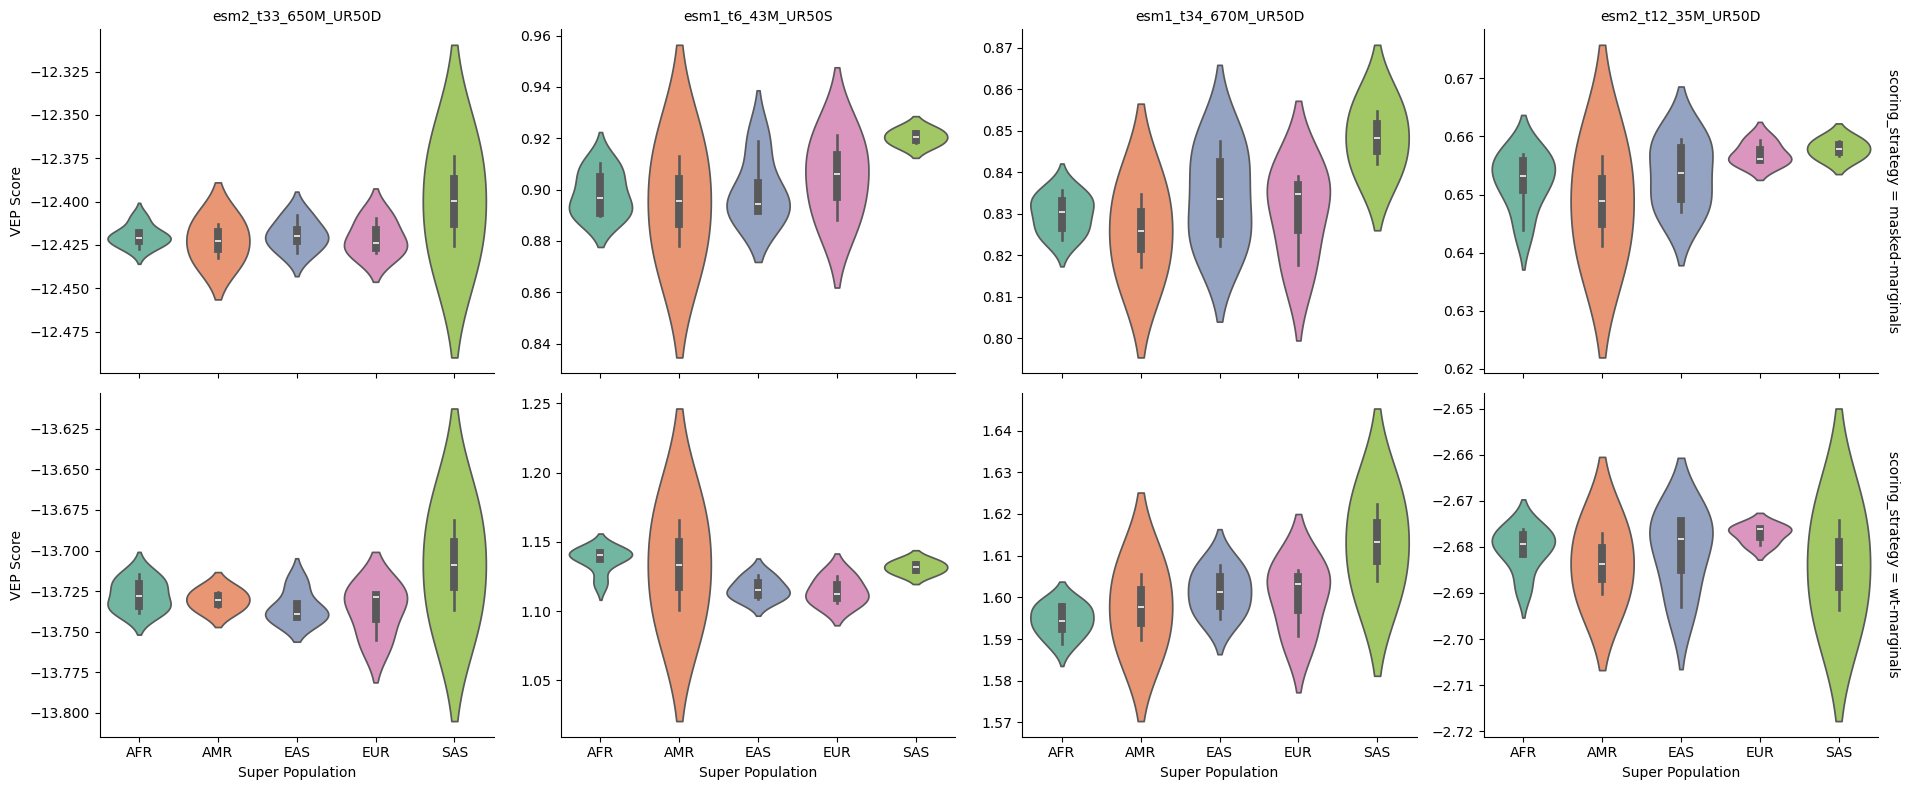

In [136]:
va.plot_population_vep_violin_unweighted(brca1, mutant="M1775R", min_freq=0.005)


### VEP by top superpopulation (weighted by superpopulation-specific haplotype frequency)

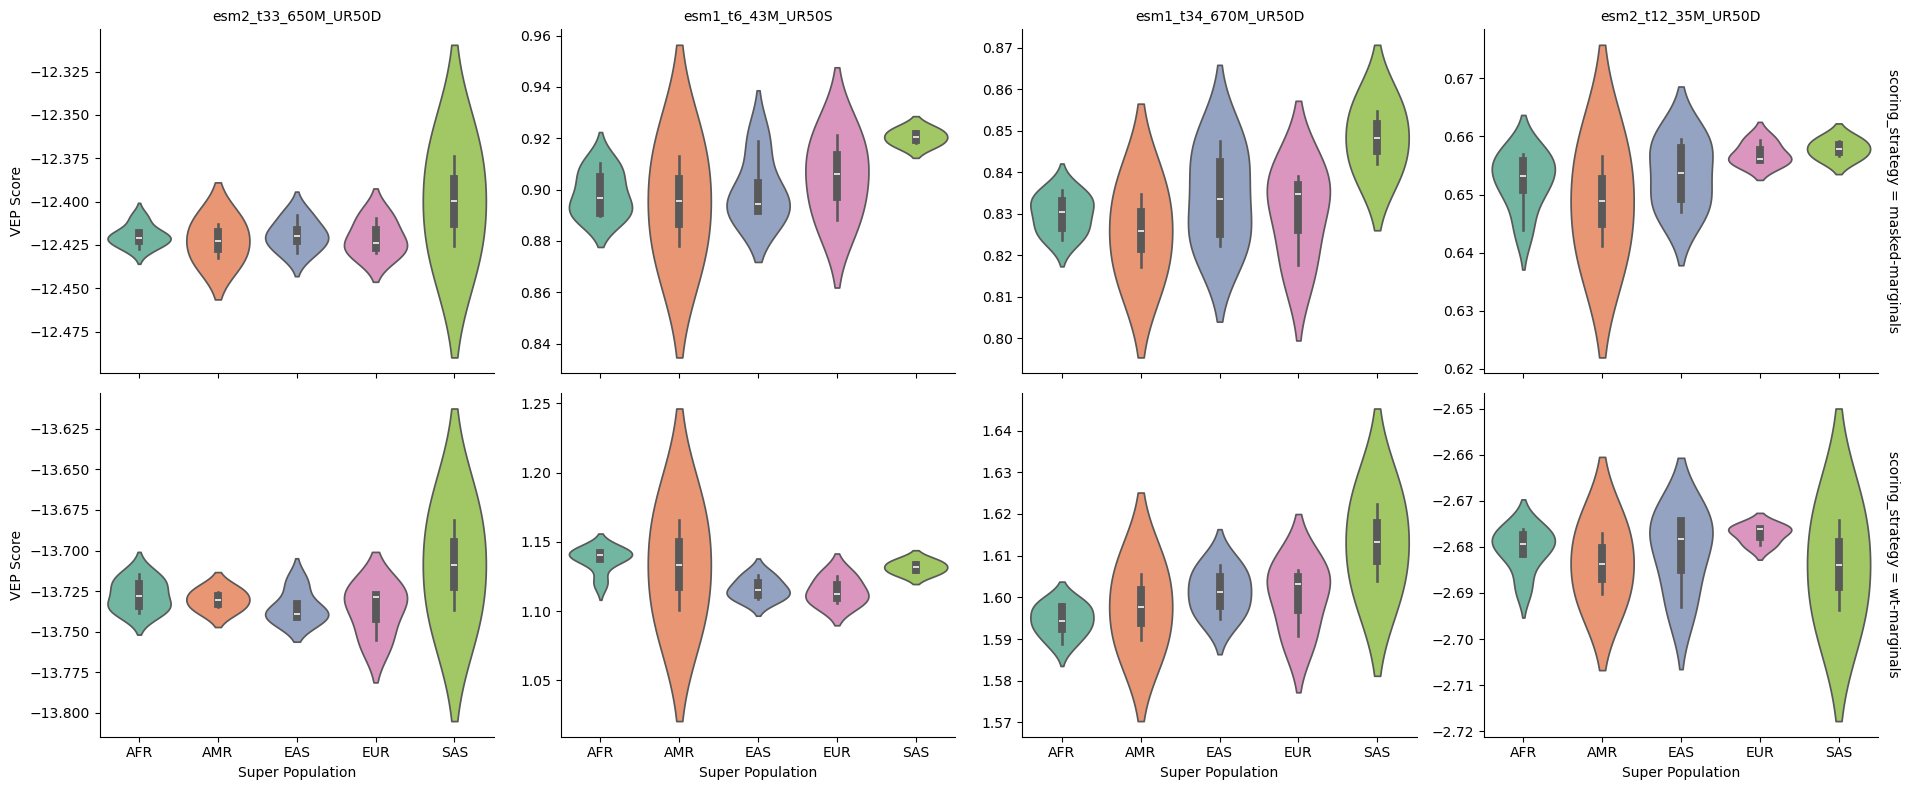

In [138]:
fig = va.plot_population_vep_violin_unweighted(brca1, 
                                               mutant="M1775R", 
                                               min_freq=0.005)

### VEP by superpopulation (weighted by ALL haplotype frequencies)

In [139]:
# Get frequencies for every population (or superpopulation), not just the top one per haplotype
brca1_freq = va.create_vep_frequency_df(brca1, 
                                        pop_col= "Super Population")

(1992720, 7)


In [144]:
brca1_freq.loc[brca1_freq['mutant']=="M1775R"].dropna(subset=['frequency','VEP']).sort_values(by=['VEP','frequency'], ascending=[True,False]).groupby(['model_location','scoring_strategy','mutant']).head(1)

,haplotype,model_location,scoring_strategy,mutant,VEP,frequency,Super Population
267778,ENSP00000350283:1783M>T,esm2_t33_650M_UR50D,wt-marginals,M1775R,-13.858065,0.000756,AFR
903184,ENSP00000350283:1710G>R,esm2_t33_650M_UR50D,masked-marginals,M1775R,-12.510061,0.001022,SAS
79463,ENSP00000350283:1720T>A,esm2_t12_35M_UR50D,wt-marginals,M1775R,-2.702299,0.001441,AMR
753173,"ENSP00000350283:871P>L,1645R>T",esm2_t12_35M_UR50D,masked-marginals,M1775R,0.633497,0.000756,AFR
1053815,ENSP00000350283:466R>Q,esm1_t34_670M_UR50D,masked-marginals,M1775R,0.796746,0.001441,AMR
1168482,ENSP00000350283:1347R>G,esm1_t6_43M_UR50S,masked-marginals,M1775R,0.874597,0.002882,AMR
527148,"ENSP00000350283:1038E>G,1613S>G",esm1_t6_43M_UR50S,wt-marginals,M1775R,1.092997,0.003976,EUR
446681,"ENSP00000350283:8V>I,841R>W,871P>L",esm1_t34_670M_UR50D,wt-marginals,M1775R,1.575886,0.000756,AFR


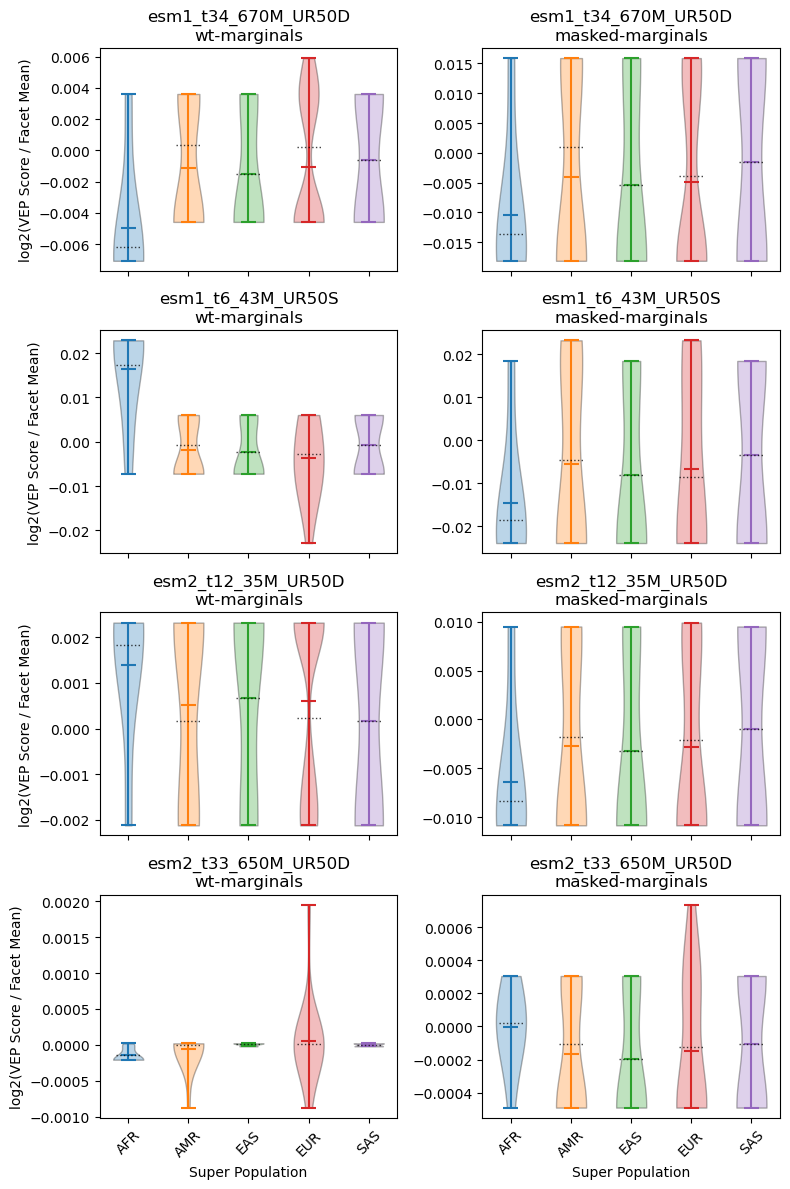

In [129]:
fig = va.plot_population_vep_violin_weighted(brca1_freq,
                                             top_pop_col='Super Population',
                                             mutant="M1775R", 
                                             min_freq=0.05, 
                                             log_fold_change=True)

## APOE

In [ ]:
# APOE-ε2 (cys112, cys158)
# APOE-ε3 (cys112, arg158)
# APOE-ε4 (arg112, arg158)

## HBB

In [56]:
gene = "SERPINA1"
hbb = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['protein'].isin(
        candidate_proteins.loc[candidate_proteins['Gene']==gene]['RefSeq Protein']
            ))]
            )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 450 masked-marginals parquet files


Reading files:   0%|          | 0/450 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 4.71GB/s]
/home/schilder/projects/VEP_protein/src/vep_analysis.py:189: DtypeWarning: Columns (0,47) have mixed types. Specify dtype option on import or set low_memory=False.
  pgd_subs_raw = pd.read_csv(pgd_resources['substitutions_raw_clinical'][0])


VEP dataframe shape: (23400, 72)


In [57]:
hbb = hs.add_haplotype_freqs(hbb) 

Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype frequencies:   0%|          | 0/1 [00:00<?, ?it/s]

Using cohorts: {'1000GENOMES:phase_3'}
Using 32 populations


Adding haplotype frequencies per population:   0%|          | 0/32 [00:00<?, ?it/s]

In [64]:
# Compute the variance of VEP scores for each mutant across all populations
vep_means = hbb.loc[hbb['mutant_in_haplotype']==False].groupby(['model_location','scoring_strategy','mutant','top_superpop'])['VEP'].mean()
vep_means_var = vep_means.groupby(['model_location','scoring_strategy','mutant']).var()
top_mutants = vep_means_var.groupby(['mutant']).mean().sort_values(ascending=False).head(10)
top_mutants 

mutant
D365Y    0.079922
R63L     0.076595
P393R    0.043534
D365N    0.035506
E366G    0.032238
P393L    0.018784
S60R     0.018048
G249R    0.017753
S77F     0.016882
L300P    0.013965
Name: VEP, dtype: float64

In [62]:
hbb_mmr = va.compute_vep_mmr(hbb.loc[hbb['scoring_strategy']=="masked-marginals"])
top_mutants = hbb_mmr.groupby(['mutant'])['rank'].mean().sort_values().head(10)
top_mutants 

Computing MMR for each model and strategy:   0%|          | 0/5 [00:00<?, ?it/s]

mutant
L278P    1.0
L300P    1.0
S77F     1.0
H286Y    2.0
H67Q     2.0
G119V    2.0
M409T    2.0
A82P     2.0
R63L     3.0
D365Y    3.0
Name: rank, dtype: object

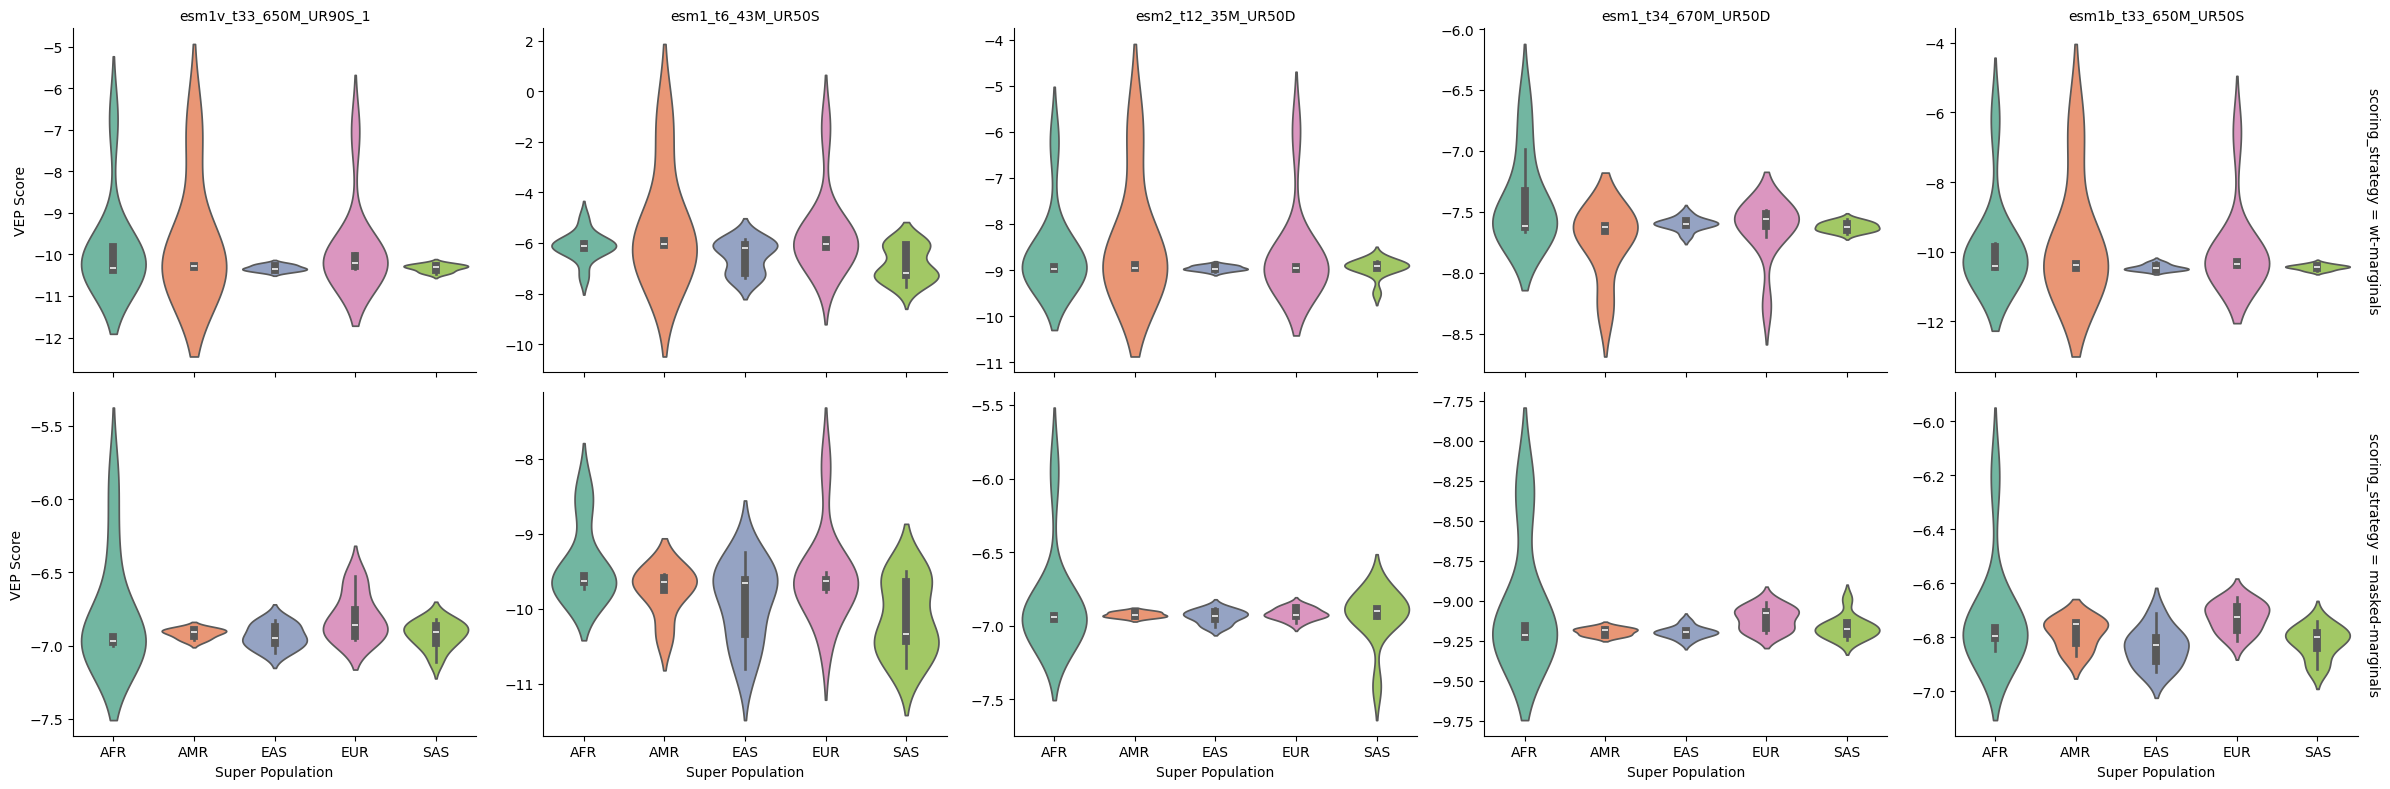

In [68]:
fig = va.plot_population_vep_violin_unweighted(hbb, 
                                               mutant=top_mutants.index[0], 
                                               min_freq=0)

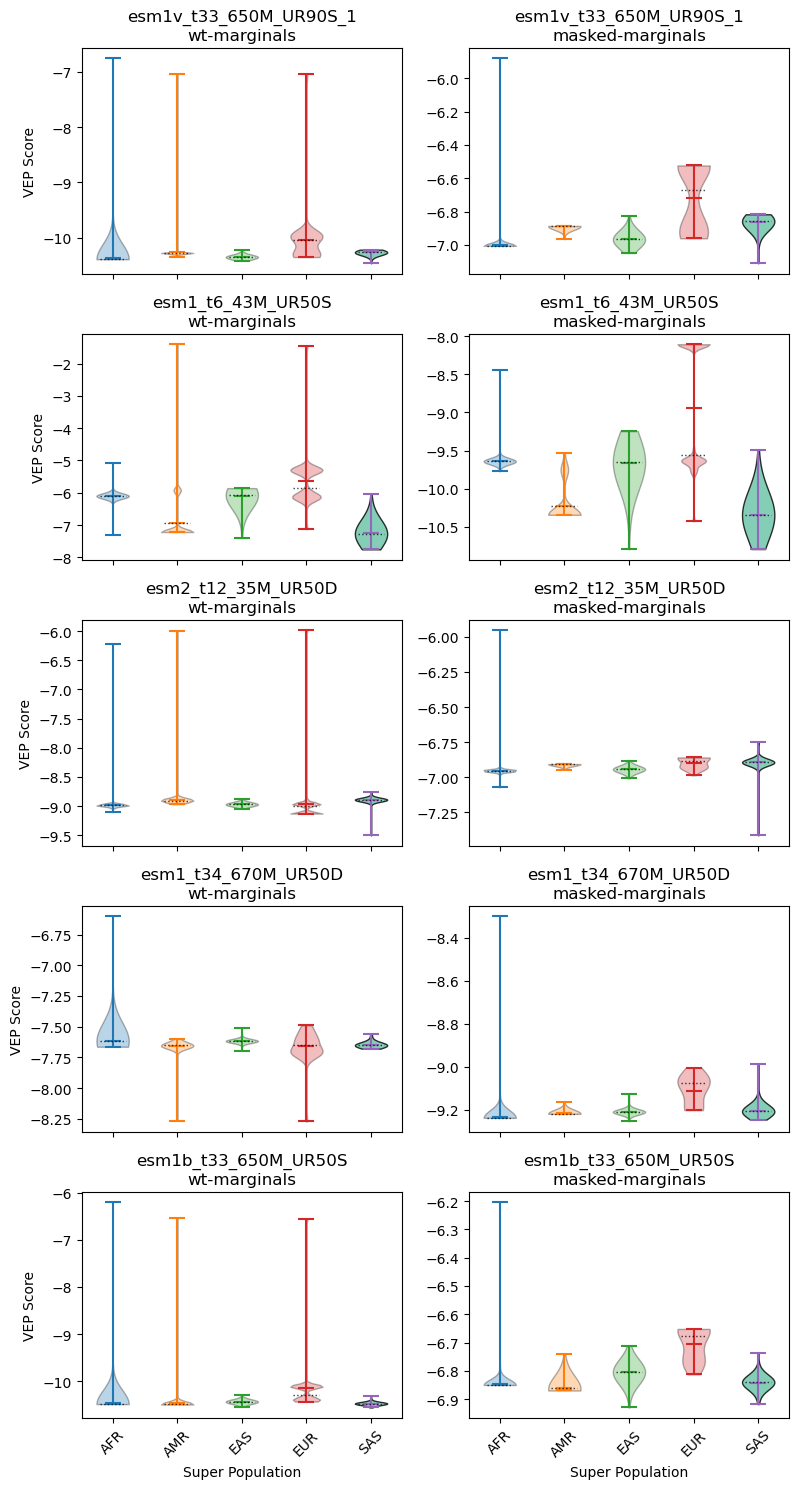

In [66]:
fig = va.plot_population_vep_violin_weighted(hbb, 
                                             mutant=top_mutants.index[0], 
                                               freq_col = 'top_superpop_freq',     
                                               min_freq=0)

### VEP by superpopulation (weighted by ALL haplotype frequencies)

In [69]:
# Get frequencies for every population (or superpopulation), not just the top one per haplotype
hbb_freq = va.create_vep_frequency_df(hbb, 
                                    pop_col= "Super Population")

(117000, 7)


In [70]:
hbb_freq.loc[hbb_freq['mutant']==hbb_mmr['mutant'].unique()[0]].dropna(subset=['frequency','VEP']).sort_values(by=['VEP','frequency'], ascending=[True,False]).groupby(['model_location','scoring_strategy','mutant']).head(1)

,haplotype,model_location,scoring_strategy,mutant,VEP,frequency,Super Population
11511,ENSP00000390299:247R>C,esm1v_t33_650M_UR90S_1,wt-marginals,L300P,-9.956064,0.002982,EUR
4647,ENSP00000390299:293H>Q,esm1b_t33_650M_UR50S,wt-marginals,L300P,-8.446716,0.002269,AFR
1579,ENSP00000390299:361V>G,esm2_t12_35M_UR50D,wt-marginals,L300P,-7.221777,0.000756,AFR
23055,ENSP00000390299:146E>K,esm1v_t33_650M_UR90S_1,masked-marginals,L300P,-6.397397,0.001022,SAS
13279,ENSP00000390299:361V>G,esm2_t12_35M_UR50D,masked-marginals,L300P,-4.396154,0.000756,AFR
16347,ENSP00000390299:293H>Q,esm1b_t33_650M_UR50S,masked-marginals,L300P,-4.363639,0.002269,AFR
17803,ENSP00000390299:288E>V,esm1_t34_670M_UR50D,masked-marginals,L300P,-2.983606,0.057637,AMR
6103,ENSP00000390299:288E>V,esm1_t34_670M_UR50D,wt-marginals,L300P,-2.823746,0.057637,AMR
8287,"ENSP00000390299:300L>R,400E>D",esm1_t6_43M_UR50S,wt-marginals,L300P,0.099747,0.000992,EAS
21027,"ENSP00000390299:125R>H,331G>R,400E>D",esm1_t6_43M_UR50S,masked-marginals,L300P,0.534792,0.001022,SAS


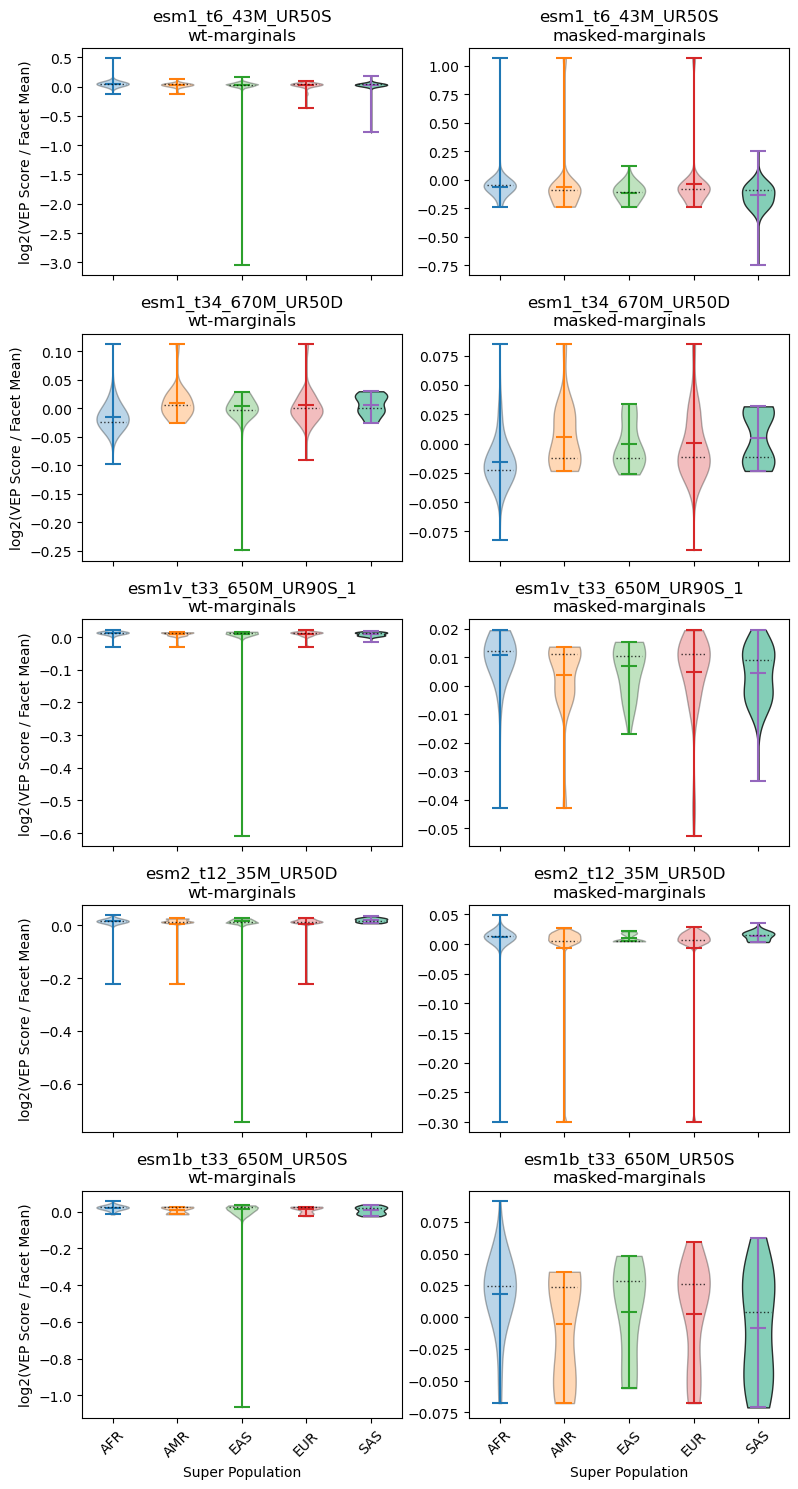

In [71]:
fig = va.plot_population_vep_violin_weighted(hbb_freq,
                                             top_pop_col='Super Population',
                                             mutant=hbb_mmr['mutant'].unique()[0], 
                                             min_freq=0, 
                                             log_fold_change=True)